# **Análisis por volumen de publicación**

En este notebook analizamos el volumen de disposiciones publicadas por distintas unidades temporales: anual, trimestre, mensual, semanal, bloque de 3 días (lunes-miércoles, jueves-domingo).

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dataset_universidades_procesado.csv")
df.head()

,ID_Disposicion,Fecha_Publicacion,Titulo_Semantico,Año_Semana,Año,Bloque_3dias,texto_limpio,texto_lower,Mes,Trimestre,Bloques_dias_semana,Dia_semana_num,Dia_semana,longitud_titulo
0,BOE-A-1995-26,1995-01-02,"Resolución de 30 de noviembre de 1994, de la U...",1995-01,1995,0,Resolucion de de noviembre de de la Universida...,resolucion de de noviembre de de la universida...,1,1995Q1,0,0,Monday,30
1,BOE-A-1995-27,1995-01-02,"Resolución de 12 de diciembre de 1994, de la U...",1995-01,1995,0,Resolucion de de diciembre de de la Universida...,resolucion de de diciembre de de la universida...,1,1995Q1,0,0,Monday,42
2,BOE-A-1995-77,1995-01-03,"Resolución de 28 de noviembre de 1994, de la U...",1995-01,1995,0,Resolucion de de noviembre de de la Universida...,resolucion de de noviembre de de la universida...,1,1995Q1,0,1,Tuesday,48
3,BOE-A-1995-78,1995-01-03,"Resolución de 13 de diciembre de 1994, de la U...",1995-01,1995,0,Resolucion de de diciembre de de la Universida...,resolucion de de diciembre de de la universida...,1,1995Q1,0,1,Tuesday,40
4,BOE-A-1995-205,1995-01-03,"Resolución de 12 de diciembre de 1994, de la U...",1995-01,1995,0,Resolucion de de diciembre de de la Universida...,resolucion de de diciembre de de la universida...,1,1995Q1,0,1,Tuesday,45


## **Anual**

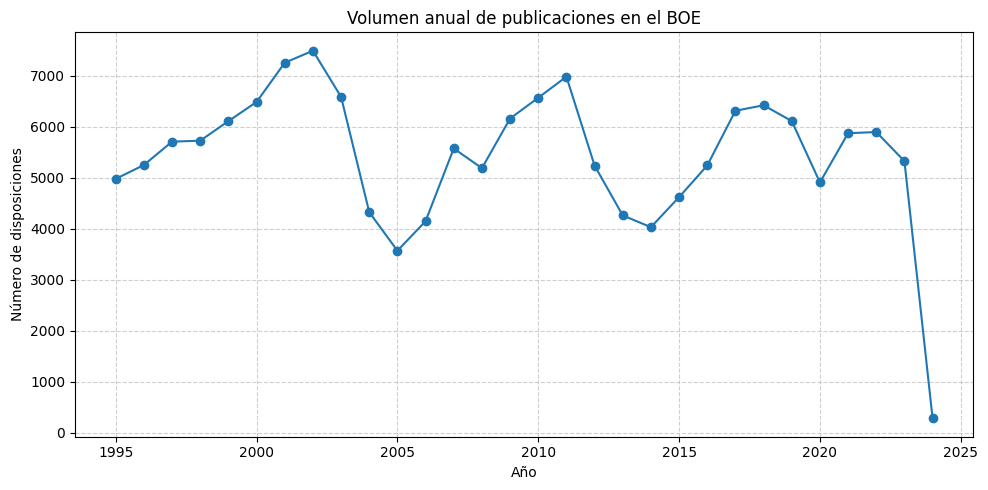

In [4]:
vol_anual = df.groupby('Año')['ID_Disposicion'].count()

plt.figure(figsize=(10,5))
plt.plot(vol_anual.index, vol_anual.values, marker='o')
plt.title('Volumen anual de publicaciones en el BOE')
plt.xlabel('Año')
plt.ylabel('Número de disposiciones')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


En la gráfica se muestra una tendencia general de crecimiento, interrumpida por tres descensos significativos en los años 2005, 2014 y 2024.

En 2005, se observa una reducción pronunciada respecto a los años anteriores. Este descenso podría asociarse con procesos de reestructuración administrativa y cambios en la gestión universitaria derivados de la adaptación al Espacio Europeo de Educación Superior (EEES), conocido como Plan Bolonia, así como con las primeras fases de digitalización del Boletín Oficial del Estado, que comenzaron a introducirse progresivamente a mediados de la década de 2000.

La caída de 2014 coincide con un periodo de ajuste institucional y económico posterior a la crisis financiera de 2008–2013. En estos años se produjeron recortes en la contratación pública y una menor actividad administrativa, lo que probablemente redujo el número de resoluciones y convocatorias emitidas.

Finalmente, la disminución observada en 2024 parece responder a un efecto de datos incompletos, ya que los registros correspondientes al año más reciente no siempre se encuentran completamente disponibles en las fuentes abiertas.

## **Trimestral**

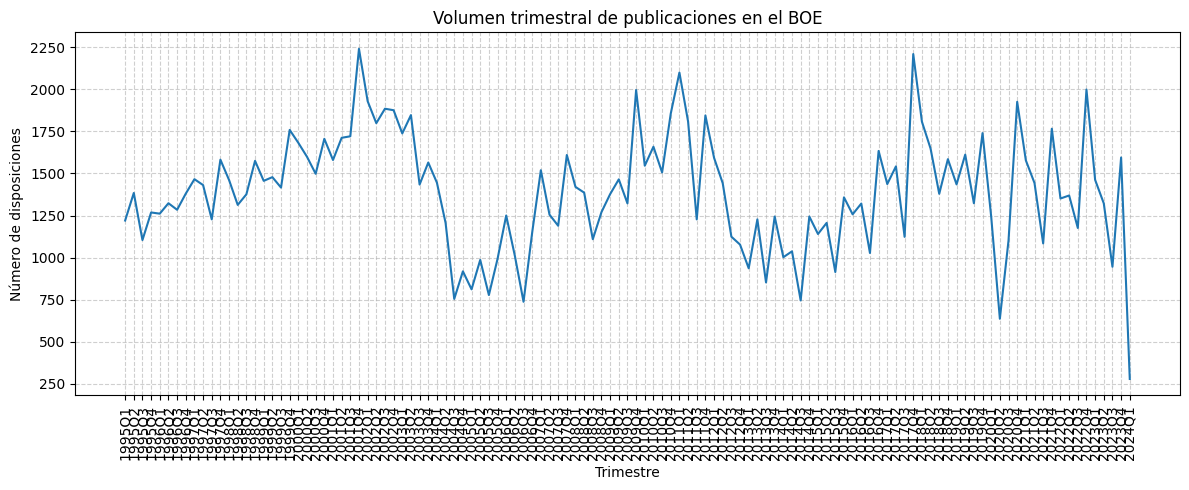

In [5]:
vol_trimestre = df.groupby('Trimestre')['ID_Disposicion'].count()

plt.figure(figsize=(12,5))
plt.plot(vol_trimestre.index, vol_trimestre.values)
plt.title('Volumen trimestral de publicaciones en el BOE')
plt.xlabel('Trimestre')
plt.ylabel('Número de disposiciones')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Aquí vemos más detalladamente una tendencia similar a la vista anualmente.

## **Mensual**

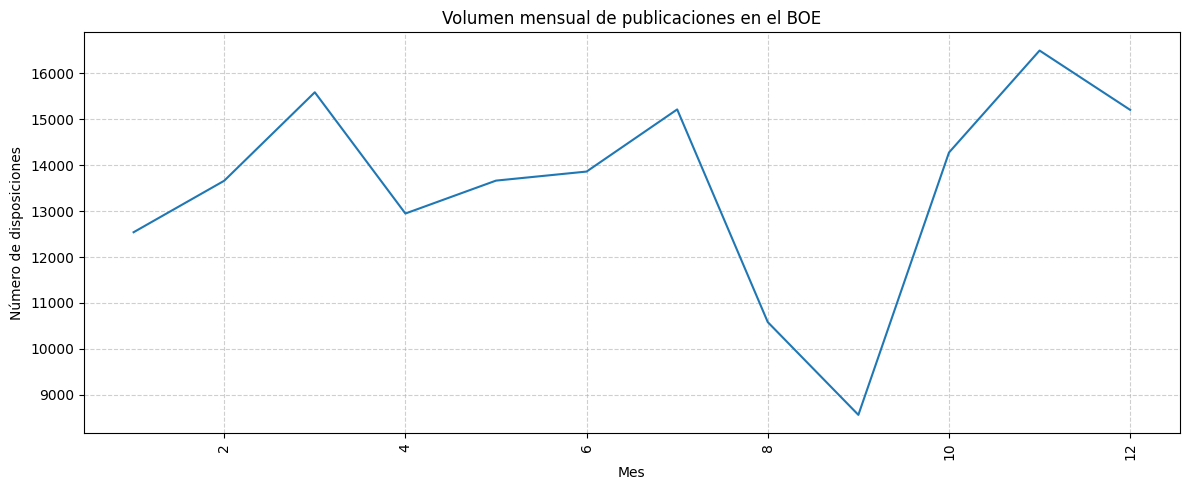

In [6]:
vol_trimestre = df.groupby('Mes')['ID_Disposicion'].count()

plt.figure(figsize=(12,5))
plt.plot(vol_trimestre.index, vol_trimestre.values)
plt.title('Volumen mensual de publicaciones en el BOE')
plt.xlabel('Mes')
plt.ylabel('Número de disposiciones')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


El análisis del volumen de disposiciones por mes revela un comportamiento estacional marcado en la actividad administrativa. En general, los meses de marzo, julio y noviembre presentan picos significativos en el número de resoluciones publicadas, mientras que septiembre muestra de forma consistente el menor volumen del año.

Este patrón puede explicarse por la organización del calendario administrativo y académico. Los aumentos de marzo y julio suelen coincidir con cierres de periodos administrativos o académicos, momentos en los que se concentran resoluciones de contratación, convocatorias y nombramientos. El incremento en noviembre puede vincularse con el cierre del ejercicio presupuestario y la necesidad de publicar disposiciones antes del fin de año.

Por el contrario, la caída en septiembre se explica probablemente por la pausa veraniega y la lenta reactivación de la actividad administrativa tras las vacaciones. En esos días, muchas oficinas aún no han retomado su ritmo habitual, lo que reduce el número de publicaciones. Este patrón se repite cada año, lo que indica que existe un comportamiento estacional regular en las disposiciones oficiales.

## **Bloque de 3 días (lunes-miércoles, jueves-domingo)**

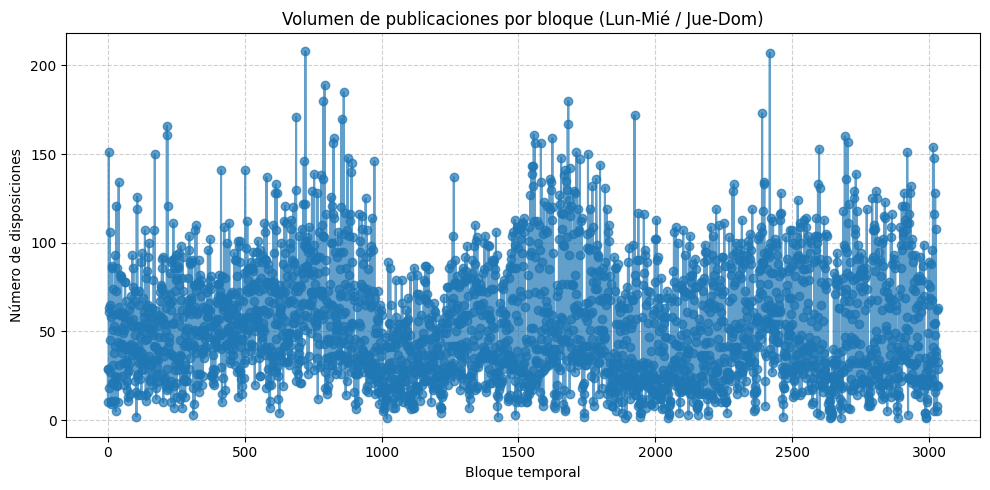

In [9]:
vol_bloque = df.groupby('Bloques_dias_semana')['ID_Disposicion'].count()

plt.figure(figsize=(10,5))
plt.plot(vol_bloque.index, vol_bloque.values, marker='o', alpha=0.7)
plt.title('Volumen de publicaciones por bloque (Lun-Mié / Jue-Dom)')
plt.xlabel('Bloque temporal')
plt.ylabel('Número de disposiciones')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


De este gráfico no podemos obtener muchas conclusiones, quizá podamos distinguir el periodo que coincide con los años ya mencionados (2005, 2014) con una reducción en el número de disposiciones.

## **Día de la semana**

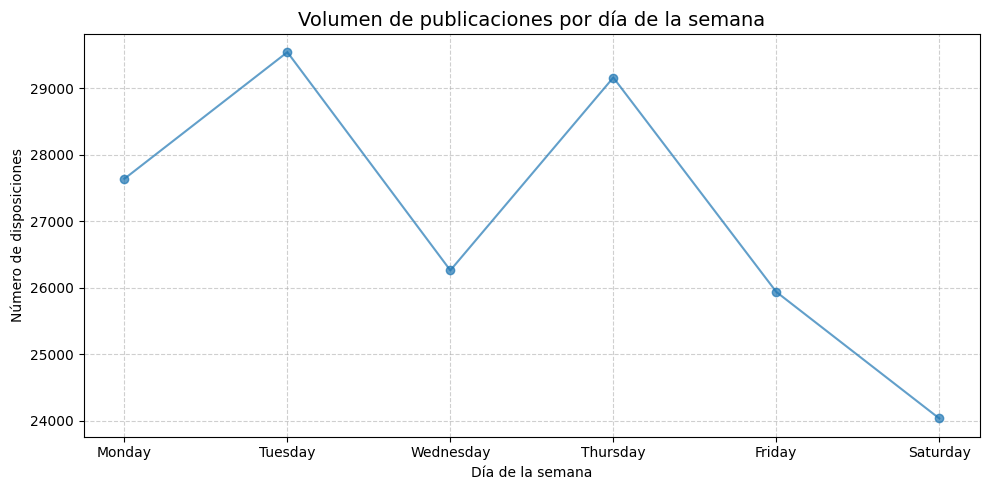

In [13]:
vol_dia = df.groupby('Dia_semana')['ID_Disposicion'].count()

# Orden correcto de los días
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Reordenar según el orden cronológico
vol_dia = vol_dia.reindex(orden_dias)

plt.figure(figsize=(10,5))
plt.plot(vol_dia.index, vol_dia.values, marker='o', alpha=0.7)
plt.title('Volumen de publicaciones por día de la semana', fontsize=14)
plt.xlabel('Día de la semana')
plt.ylabel('Número de disposiciones')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


El análisis de la distribución de publicaciones por día de la semana muestra que la mayor actividad se concentra los martes y los jueves, mientras que los sábados presentan el volumen más bajo. Aunque las diferencias no son muy pronunciadas —en torno a unas 2.000 disposiciones más respecto a otros días—, el patrón refleja el funcionamiento habitual de la administración pública, con mayor carga de trabajo y publicación en los días centrales de la semana.

El descenso de los fines de semana, especialmente el sábado, es coherente con la inactividad administrativa y la ausencia de nuevas resoluciones en días no laborables.